## p(D|T, R, r, m, s, Teff) from simulated populations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import R_earth, R_sun, au
from pdetutils import *

import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (10,6)
from matplotlib import rc
rc('text', usetex=False)
import warnings
warnings.filterwarnings("ignore")

In [2]:
class PlanetSampler:
    def __init__(self, df):
        self.period = np.asarray(df.period)
        self.prad = np.asarray(df.planet_radius)
        self.Npl = len(df)

    def sample(self, n):
        idx = np.random.randint(0, self.Npl, n)
        return self.period[idx], self.prad[idx]

    def get_all(self):
        return self.period, self.prad


def marginal_pdet(star, period, prad, cdpp_func, include_transit_prob=False):
    depth_ppm = (prad / star.rad)**2 * 1e6
    dur_hr = 13 * (period / 365.25)**(1./3.) * star.rad * star.Mass**(-1./3.) * np.pi / 4.
    transit_sn = depth_ppm * np.sqrt(star.dataspan * star.dutycycle / period) / cdpp_func(star.kepid, dur_hr)
    transit_prob = (R_sun/au).value * star.rad * (period / 365.25)**(-2./3.) * star.Mass**(-1./3.)
    det_prob = p_det(transit_sn) 
    if include_transit_prob:
        det_prob *= transit_prob
    return np.mean(det_prob)


def compute_marginal_pdet(dkic, psampler, nsample=1000, include_transit_prob=False):
    period, prad = psampler.sample(nsample)
    interp = CDPPInterpolatorByKIC.from_df(dkic, kic_col="KIC")
    probs = []
    for i in range(len(dkic)):
        star = dkic.iloc[i]
        probs.append(marginal_pdet(star, period, prad, interp, include_transit_prob=include_transit_prob))
    probs = np.array(probs)
    return probs

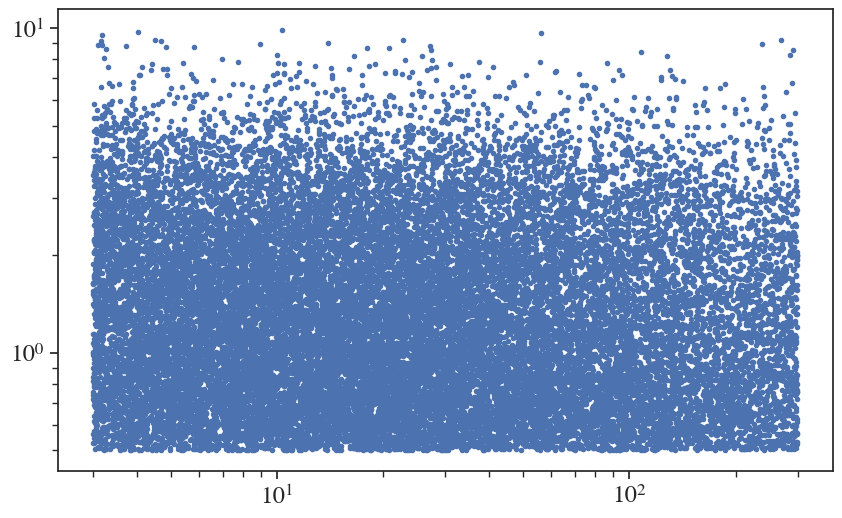

In [3]:
dp = pd.read_csv("data/physical_catalog.csv", comment='#')
dp['b'] = ((dp['period']/365.25)**2 * dp['star_mass'])**(1./3.) * np.cos(dp['incl']) * (1 - dp['ecc']**2) / (1 + dp['ecc'] * np.sin(dp['omega'])) / dp['star_radius'] * (au / R_sun).value
dtra = dp[np.abs(dp.b) < 1.].reset_index(drop=True)

plt.xscale('log')
plt.yscale('log')
plt.plot(dtra['period'], dtra['planet_radius']*R_sun/R_earth, '.');

In [4]:
psampler = PlanetSampler(dtra)

In [5]:
dkic1 = pd.read_csv("data_m15/m15_kic.csv")
dkic2 = pd.read_csv("data/DR2PapTable1.txt", delimiter='&')
dkic = pd.merge(dkic1, dkic2[['KIC', 'rad']], on='KIC')
dkic = dkic[dkic['rrmscdpp12p0']==dkic['rrmscdpp12p0']].reset_index(drop=True)

In [6]:
dkic['pdet'] = compute_marginal_pdet(dkic, psampler)
dkic['pdettra'] = compute_marginal_pdet(dkic, psampler, include_transit_prob=True)

In [7]:
dkic.to_csv("m15_kic_w_pdet_TR.csv", index=False)

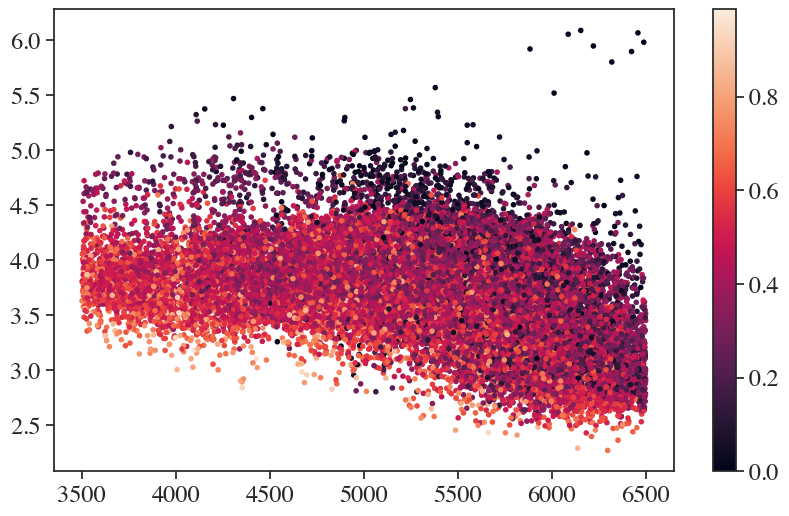

In [8]:
plt.scatter(dkic.Teff, dkic.logr, c=dkic.pdet, marker='.')
plt.colorbar();

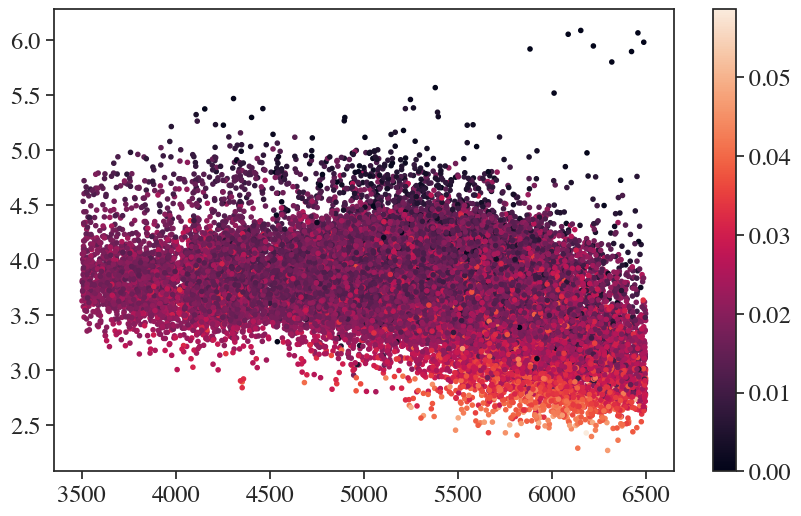

In [9]:
plt.scatter(dkic.Teff, dkic.logr, c=dkic.pdettra, marker='.')
plt.colorbar();

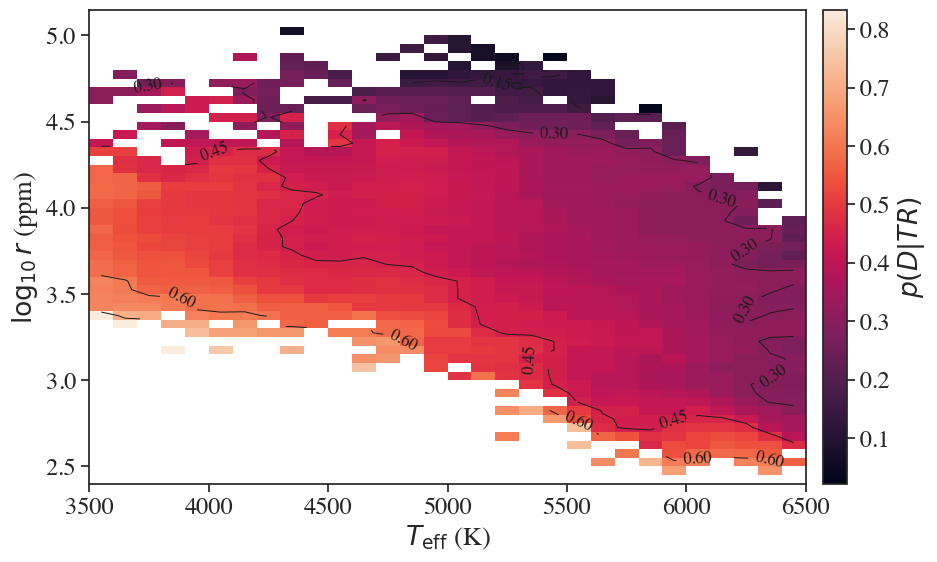

In [10]:
fig = plot_pdet_contour(dkic, xcol='Teff')
#fig.savefig('figs/m15_pdet.png', dpi=200, bbox_inches='tight')

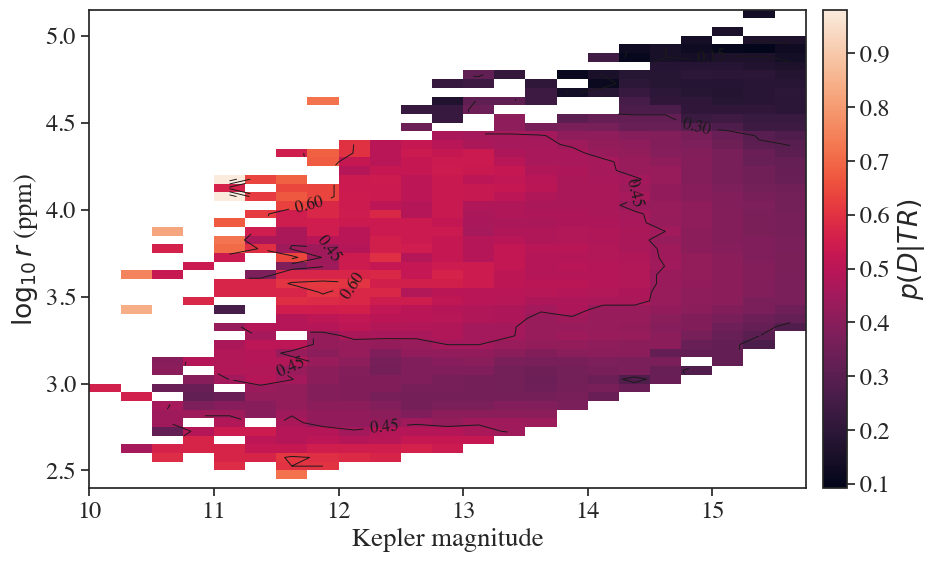

In [11]:
fig = plot_pdet_contour(dkic, xcol='kepmag', x_edges=np.arange(10, 16, 0.25))

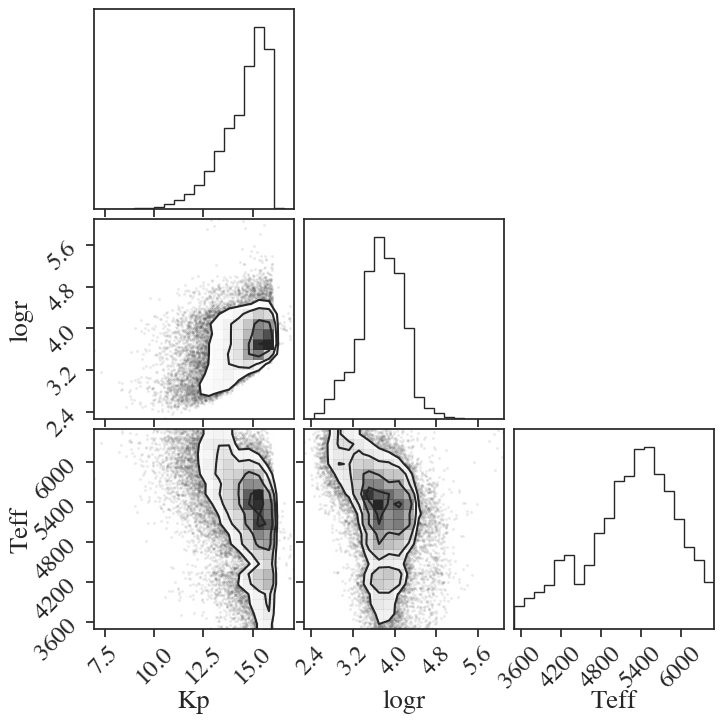

In [12]:
import corner 
fig = corner.corner(np.array(dkic[['kepmag', 'logr', 'Teff']]), labels=['Kp', 'logr', 'Teff'])

### impacts of pdet and pdet * ptra on logR vs Teff

In [13]:
from plotutils import plot 
dkoi = pd.read_csv("data_m15/m15_koi.csv")

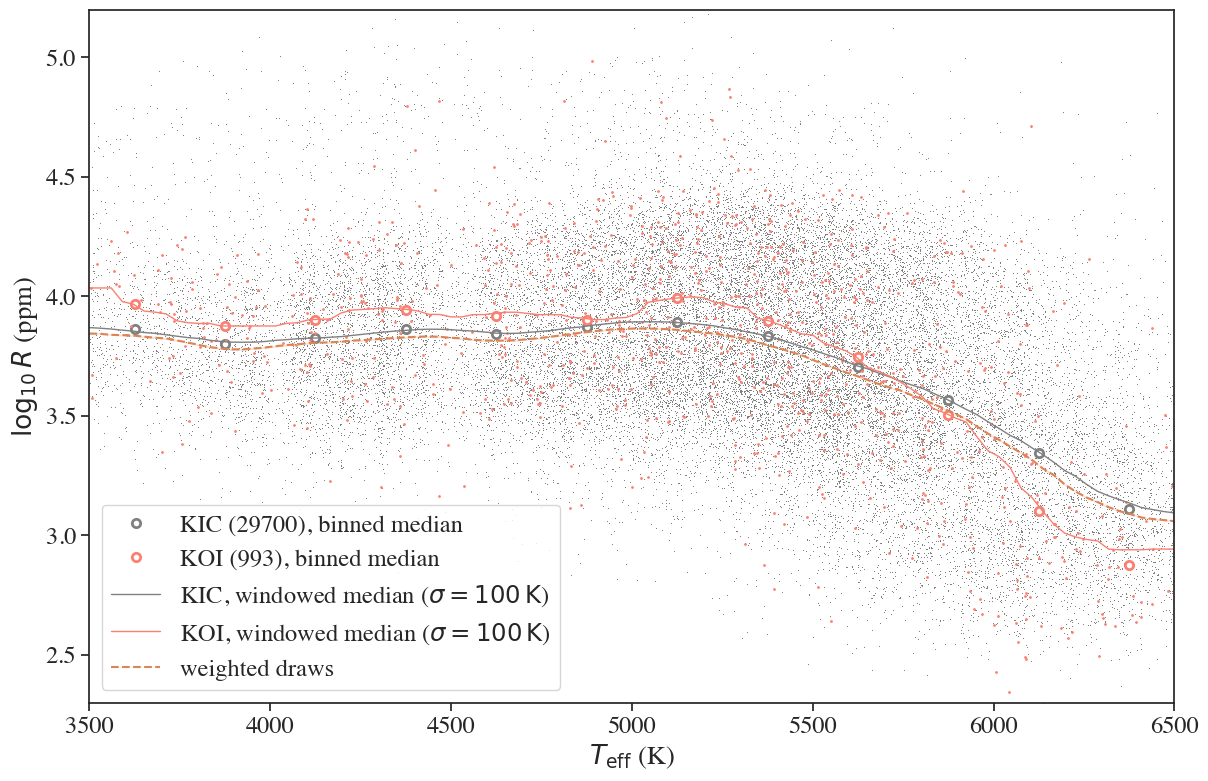

In [14]:
fig = plot(dkic, dkoi, weight_samples=np.atleast_2d(dkic.pdet).T, weight_side='kic')
plt.savefig("figs/m15_pdet-weighted.png", dpi=200, bbox_inches='tight')

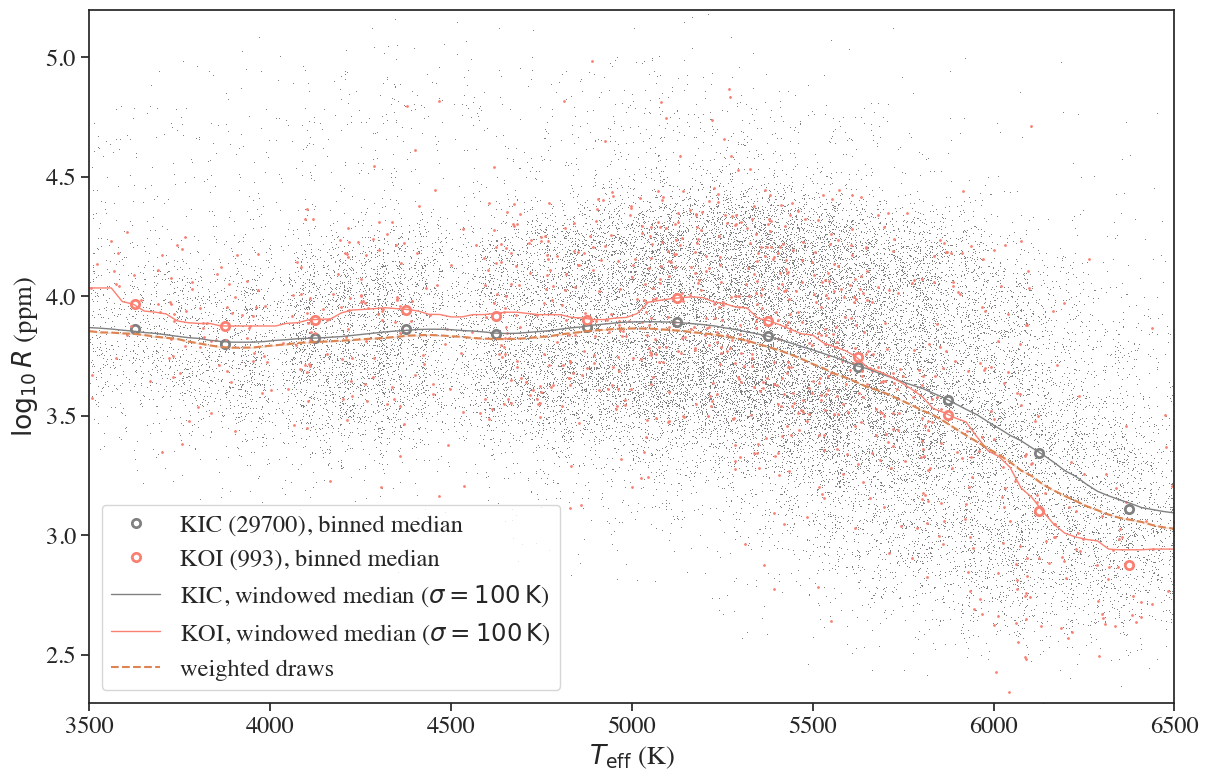

In [15]:
fig = plot(dkic, dkoi, weight_samples=np.atleast_2d(dkic.pdettra).T, weight_side='kic')
plt.savefig("figs/m15_pdettra-weighted.png", dpi=200, bbox_inches='tight')

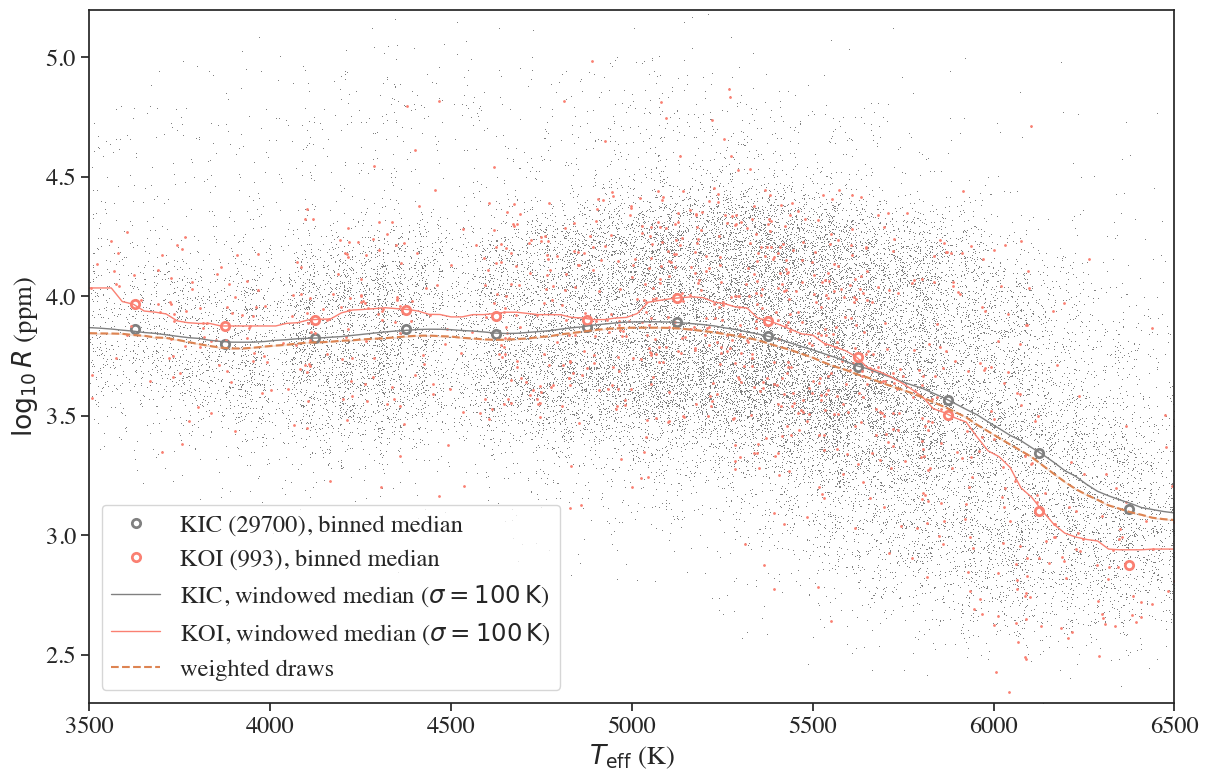

In [16]:
# turn off stellar radius dependence in ptra
fig = plot(dkic, dkoi, weight_samples=np.atleast_2d(dkic.pdettra/dkic.rad).T, weight_side='kic')
#plt.savefig("figs/m15_pdettra-weighted.png", dpi=200, bbox_inches='tight')

### impacts of pdet and pdet * ptra on rmx distributions

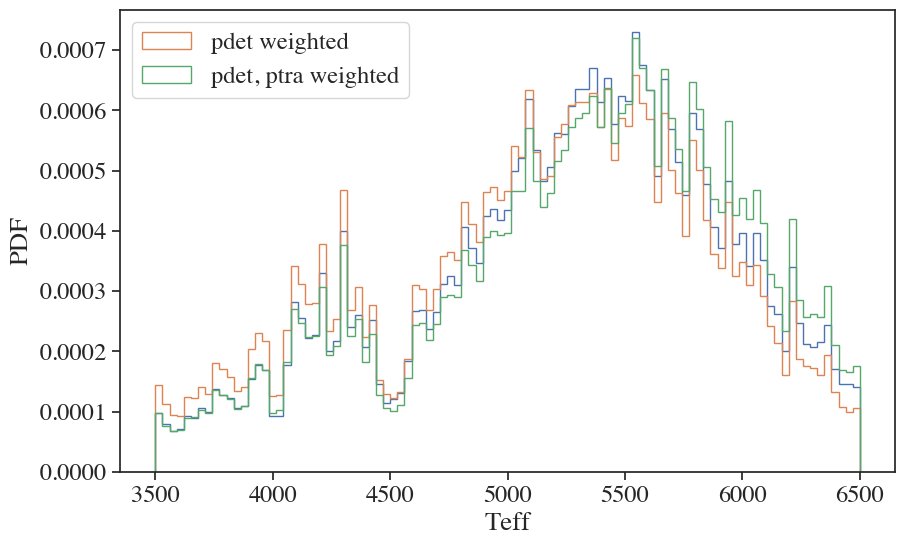

In [17]:
key = 'Teff'
bins = np.linspace(3500, 6500, 100)
plt.xlabel(key)
plt.ylabel('PDF')
plt.hist(dkic[key], bins=bins, histtype='step', lw=1, density=True)
plt.hist(dkic[key], weights=dkic.pdet, bins=bins, histtype='step', lw=1, density=True, label='pdet weighted')
plt.hist(dkic[key], weights=dkic.pdettra, bins=bins, histtype='step', lw=1, density=True, label='pdet, ptra weighted')
plt.legend(loc='best');

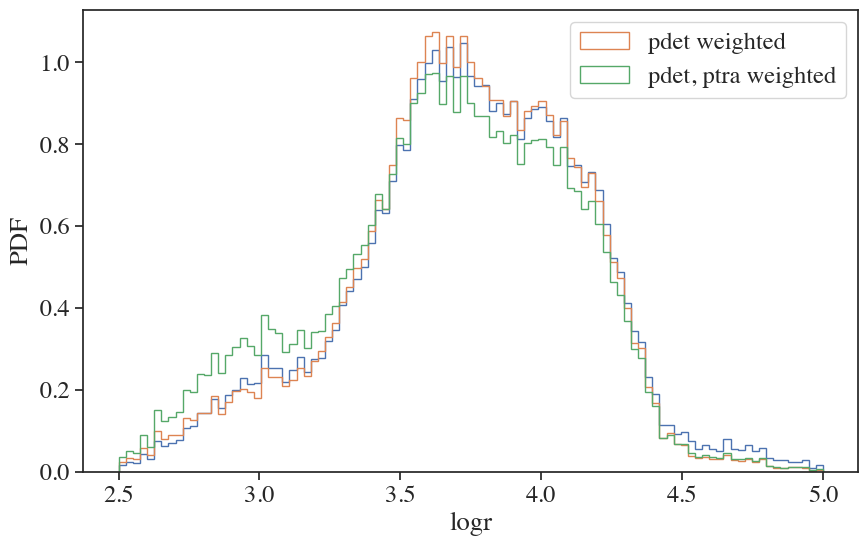

In [18]:
key = 'logr'
bins = np.linspace(2.5, 5, 100)
plt.xlabel(key)
plt.ylabel('PDF')
plt.hist(dkic[key], bins=bins, histtype='step', lw=1, density=True)
plt.hist(dkic[key], weights=dkic.pdet, bins=bins, histtype='step', lw=1, density=True, label='pdet weighted')
plt.hist(dkic[key], weights=dkic.pdettra, bins=bins, histtype='step', lw=1, density=True, label='pdet, ptra weighted')
plt.legend(loc='best');

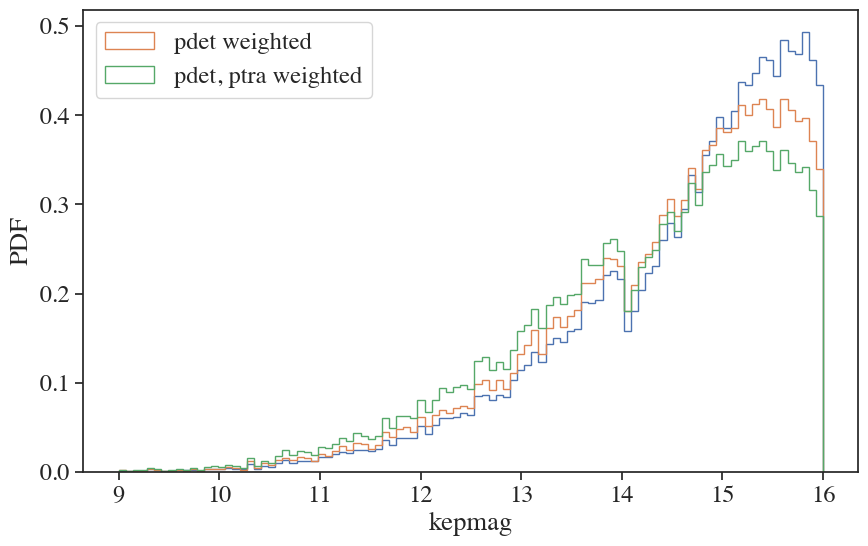

In [19]:
key = 'kepmag'
bins = np.linspace(9, 16, 100)
plt.xlabel(key)
plt.ylabel('PDF')
plt.hist(dkic[key], bins=bins, histtype='step', lw=1, density=True)
plt.hist(dkic[key], weights=dkic.pdet, bins=bins, histtype='step', lw=1, density=True, label='pdet weighted')
plt.hist(dkic[key], weights=dkic.pdettra, bins=bins, histtype='step', lw=1, density=True, label='pdet, ptra weighted')
plt.legend(loc='best');

### test pdet sampler

In [20]:
pdetsampler = PdetSampler(dkic, k=200, seed=1, sigma_T=100., sigma_logr=0.1, sigma_kepmag=0.2)

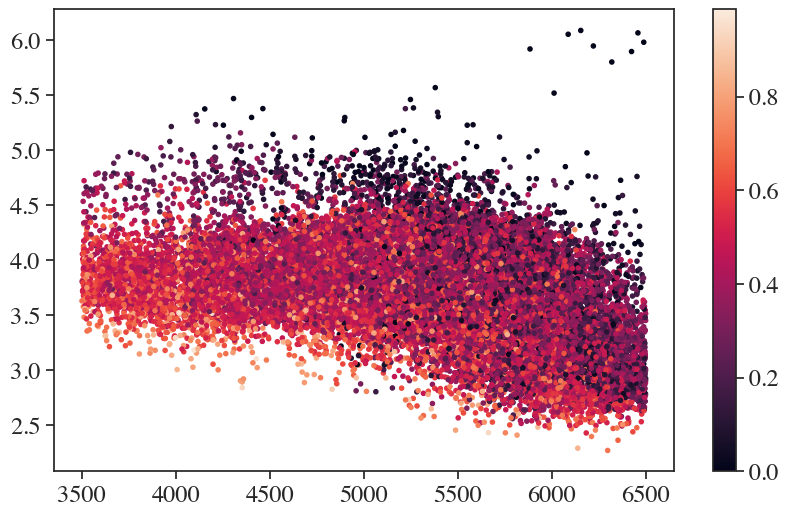

In [21]:
pdet_sample = pdetsampler.sample(dkic.logr, dkic.kepmag, dkic.Teff)
plt.scatter(dkic.Teff, dkic.logr, c=pdet_sample, marker='.')
plt.colorbar();

In [22]:
d_ = dkic.copy()
d_['pdet_sample'] = pdet_sample

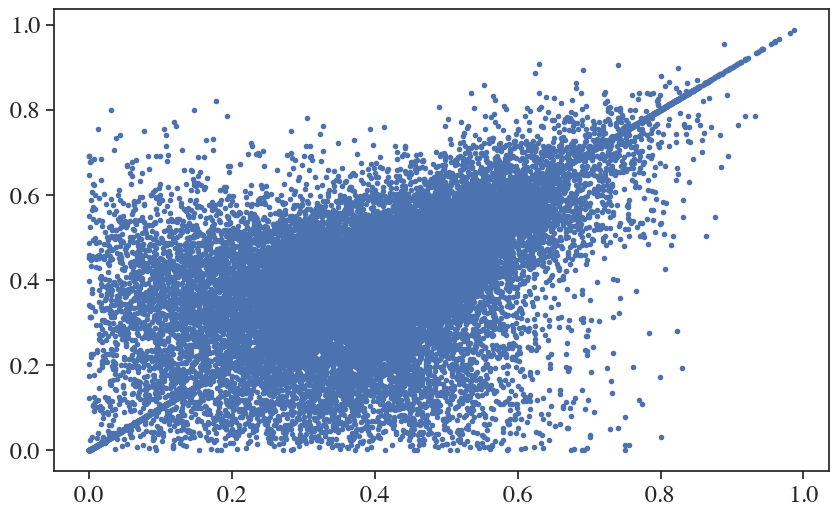

In [23]:
plt.plot(d_.pdet, d_.pdet_sample, '.')

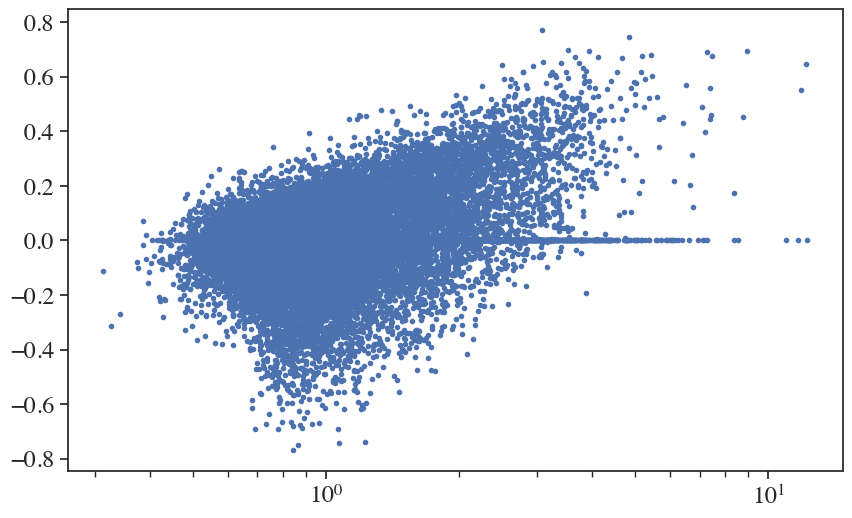

In [24]:
plt.xscale('log')
plt.plot(d_.rad, d_.pdet_sample-d_.pdet, '.')

In [48]:
pdetsampler = PdetSamplerR(dkic, k=200, seed=1, sigma_rad=0.1, sigma_kepmag=0.1)

In [49]:
pdet_sample = pdetsampler.sample(dkic.logr, dkic.kepmag, dkic.Teff, dkic.rad)

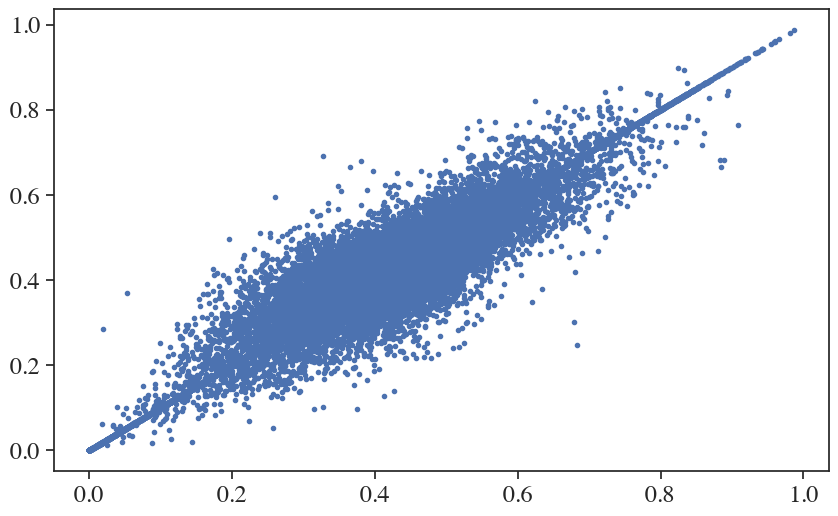

In [50]:
plt.plot(dkic.pdet, pdet_sample, '.')

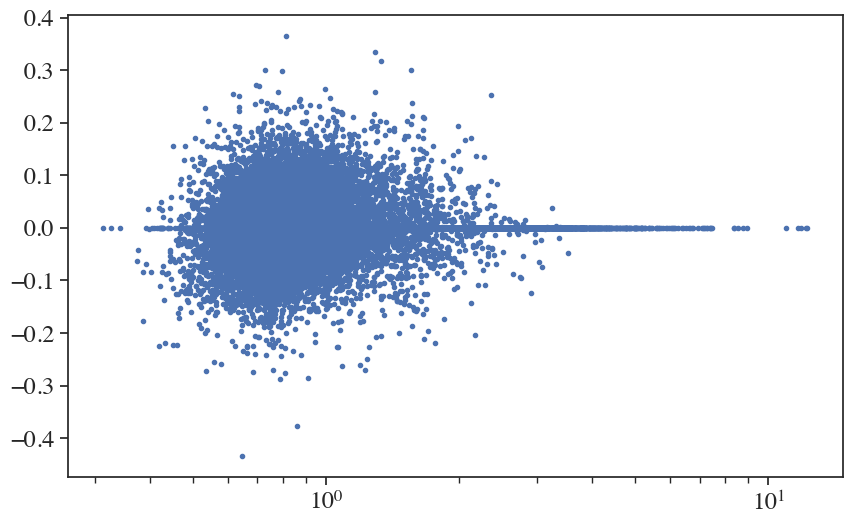

In [51]:
plt.xscale('log')
plt.plot(dkic.rad, pdet_sample-dkic.pdet, '.')

In [52]:
np.std(pdet_sample-dkic.pdet)

0.04729081830305756

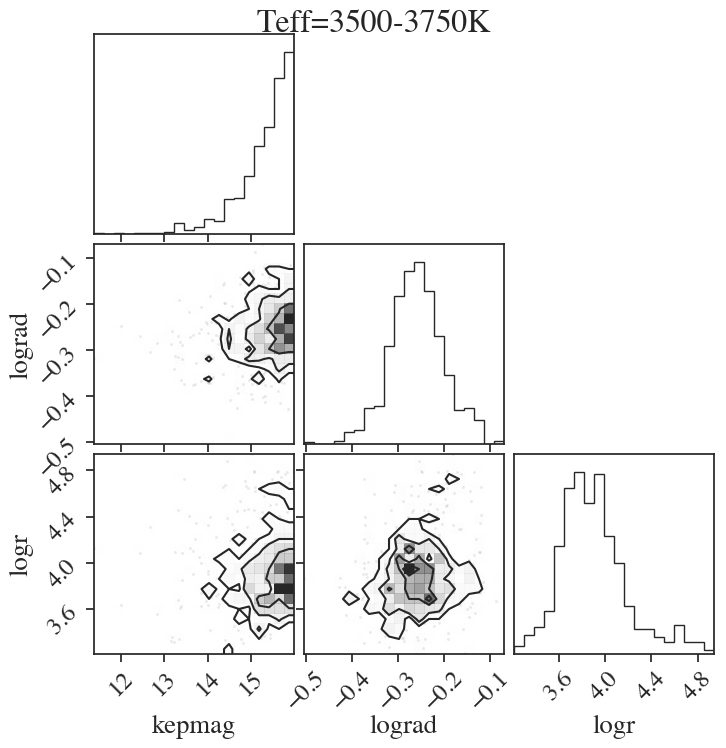

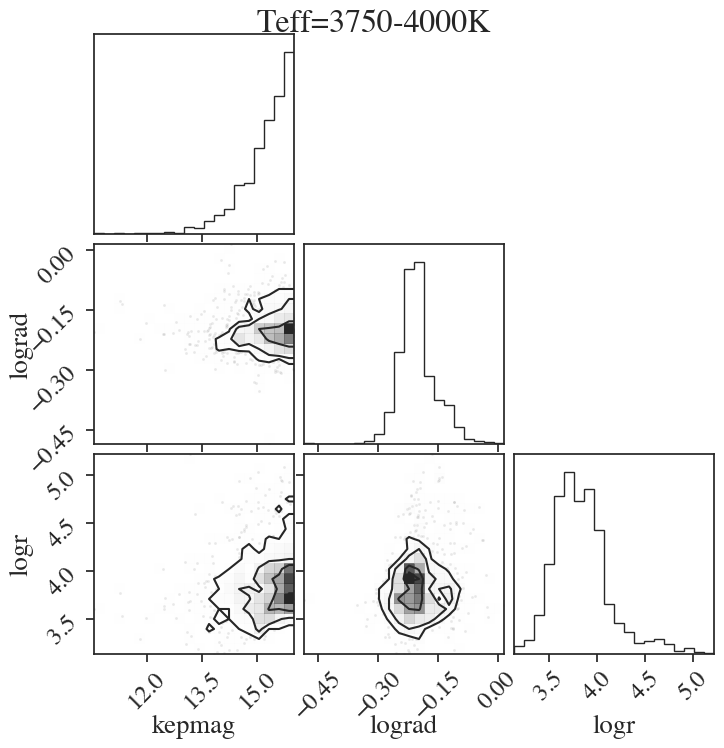

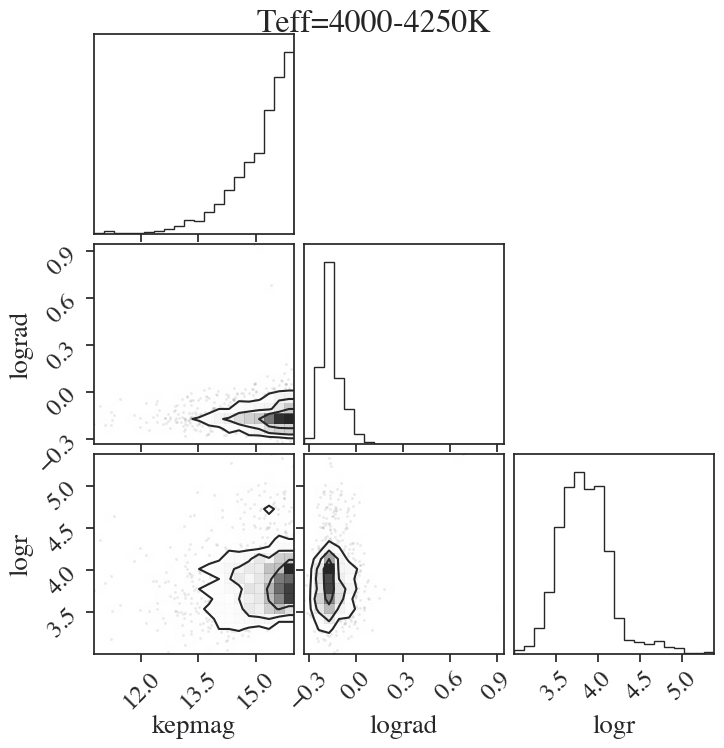

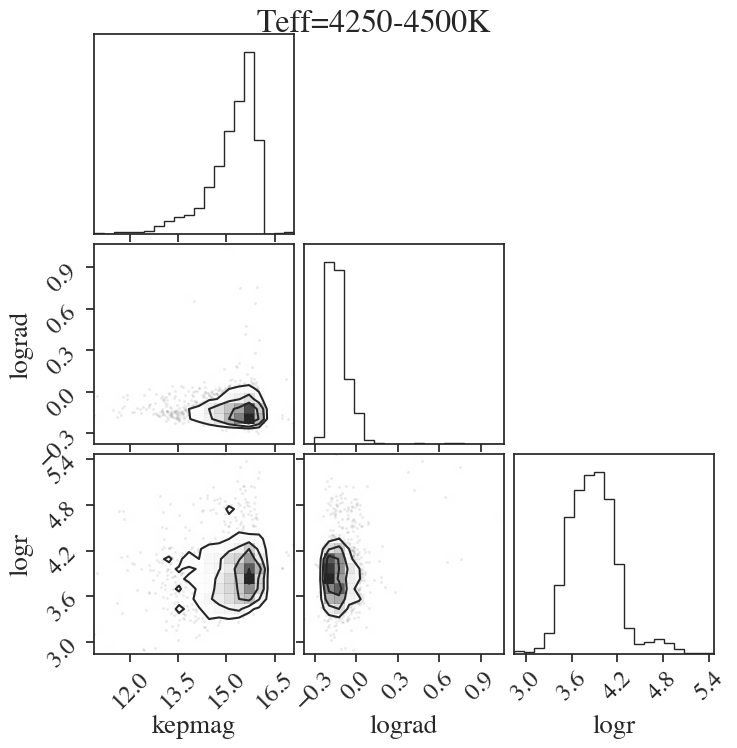

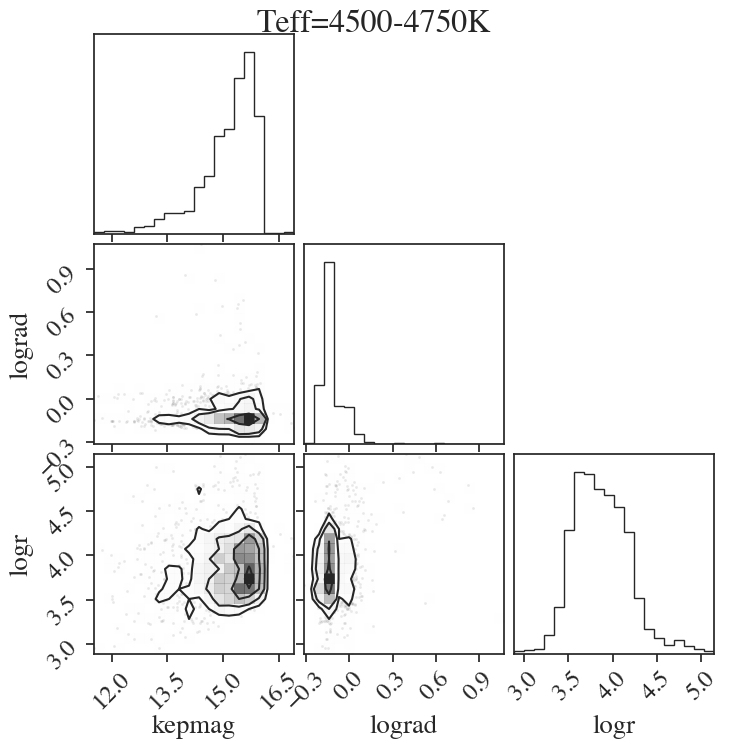

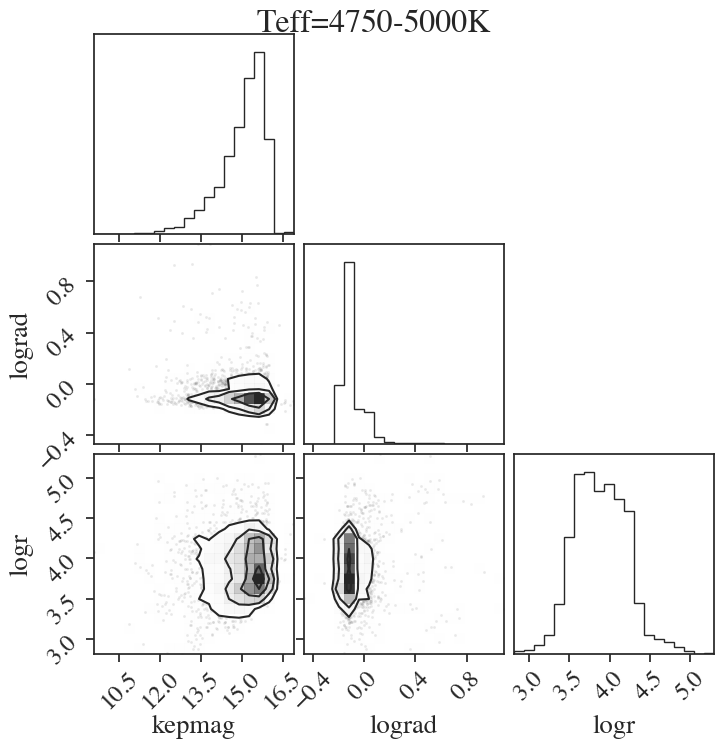

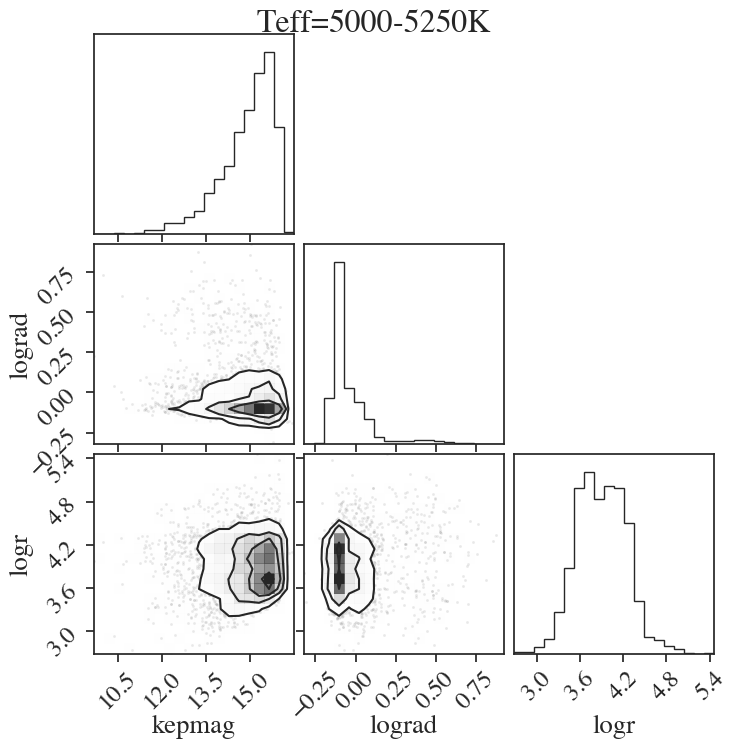

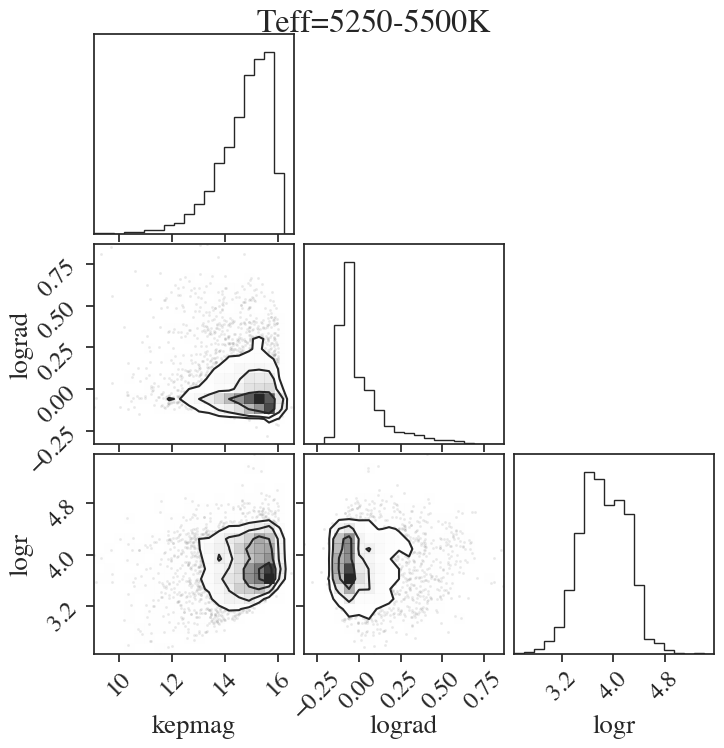

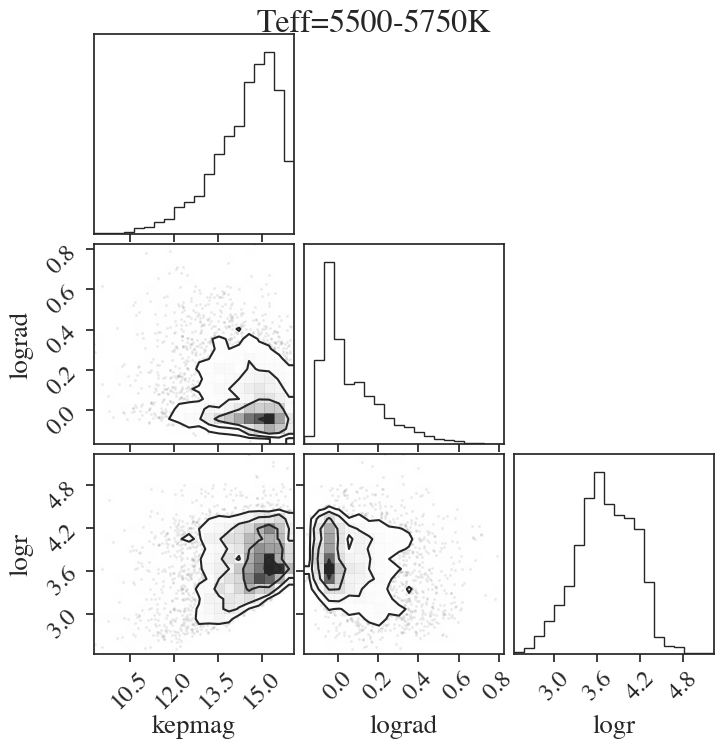

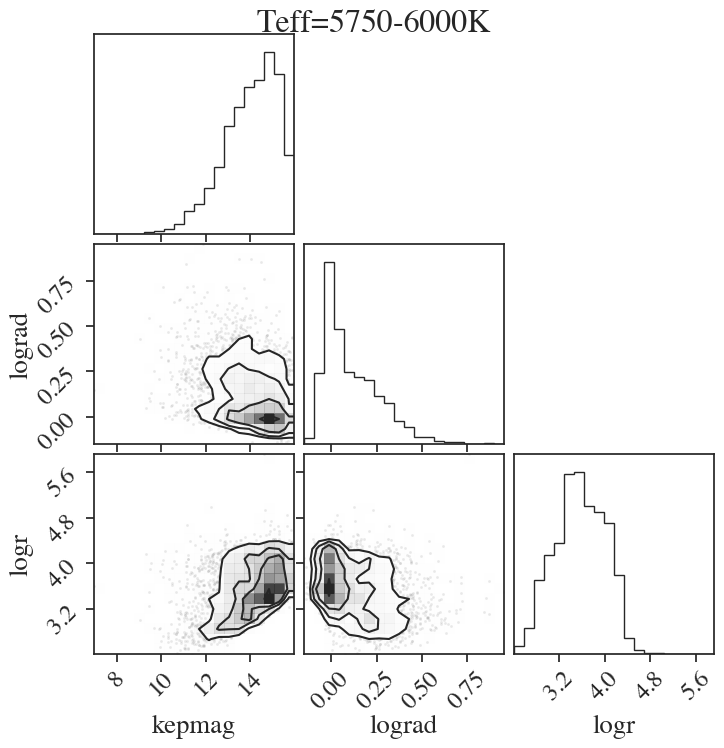

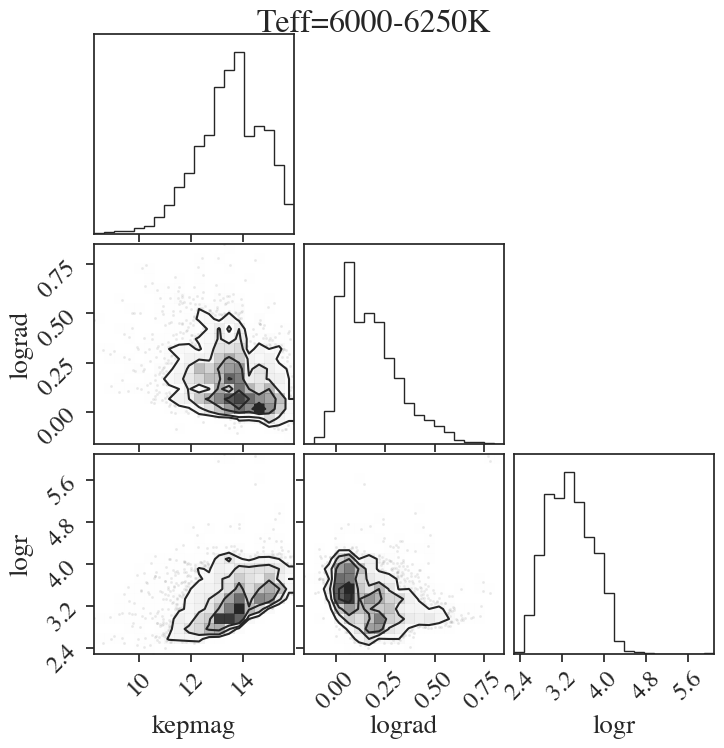

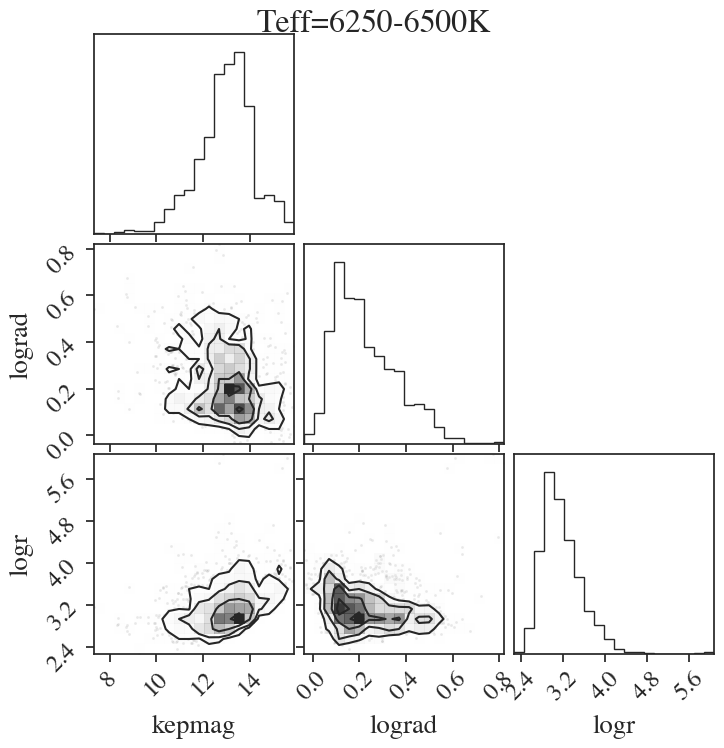

In [47]:
dkic['lograd'] = np.log10(dkic['rad'])
teff_bins = np.arange(3500, 6501, 250)
for i in range(len(teff_bins)-1):
    idx = (teff_bins[i] < dkic.Teff) & (dkic.Teff < teff_bins[i+1])
    fig = corner.corner(np.array(dkic[idx][['kepmag', 'lograd', 'logr']]), labels=['kepmag', 'lograd', 'logr'])
    fig.suptitle(f"Teff={teff_bins[i]}-{teff_bins[i+1]}K")

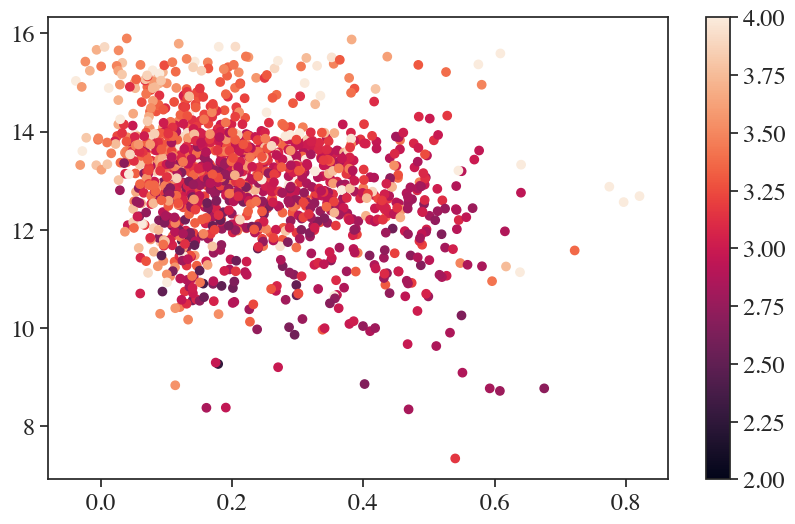

In [81]:
plt.scatter(dkic[idx].lograd, dkic[idx].kepmag, marker='o', c=dkic[idx].logr, vmin=2, vmax=4)
plt.colorbar()